# Phase 2 - YOLO Parking Space Detection (Augmented Dataset)

This notebook fine-tunes YOLOv8 for parking space detection using the **augmented JSON-format dataset**.

**Features:**
- Fine-tunes YOLOv8 on 2 classes (free, occupied parking spaces)
- Uses augmented dataset at `data/processed/parking_dataset_augmented/`
- JSON format annotations (converted to YOLO format)
- Train/val split from dataset
- Checkpoint saving (automatic via YOLO)
- Training metrics visualization
- Sample prediction visualization
- Common evaluation metrics for comparison

**Differences from Phase 1:**
- 2 classes instead of 3 (free vs occupied only)
- JSON annotations (converted to YOLO format)
- Much larger dataset (~36k images)

## 1. Imports & Path Setup

In [1]:
import zipfile
from pathlib import Path
import shutil

print("Extracting uploaded ZIP files...")
print("="*60)

# Get all ZIP files in current directory
zip_files = list(Path("/content").glob("*.zip"))
print(f"Found {len(zip_files)} ZIP file(s):")
for zf in zip_files:
    print(f"  - {zf.name}")

# Extract all ZIPs
for zip_file in zip_files:
    print(f"\nExtracting {zip_file.name}...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"✓ Extracted {zip_file.name}")

print("\n" + "="*60)
print("Checking extracted contents...")
print("="*60)

# Look for the dataset
YOLO_DATASET_DIR = Path("/content/yolo_parking_phase2")

if not YOLO_DATASET_DIR.exists():
    # Maybe it extracted with a different name, let's find it
    print("\nSearching for yolo_parking_phase2 folder...")
    for item in Path("/content").iterdir():
        if item.is_dir() and "yolo" in item.name.lower():
            print(f"Found: {item.name}")
            YOLO_DATASET_DIR = item
            break

# Verify the structure
print(f"\nDataset location: {YOLO_DATASET_DIR}")

if YOLO_DATASET_DIR.exists():
    print("\nVerifying dataset structure:")
    for split in ['train', 'val', 'test']:
        img_dir = YOLO_DATASET_DIR / "images" / split
        lbl_dir = YOLO_DATASET_DIR / "labels" / split

        if img_dir.exists():
            img_count = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
            lbl_count = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
            print(f"  ✓ {split.capitalize()}: {img_count:,} images, {lbl_count:,} labels")
        else:
            print(f"  ✗ {split.capitalize()}: folder not found!")

    yaml_path = YOLO_DATASET_DIR / "data.yaml"
    print(f"  ✓ data.yaml: {yaml_path.exists()}")

    print("\n" + "="*60)
    print("✓ DATASET READY!")
    print("="*60)
else:
    print("✗ Dataset not found after extraction")
    print("\nShowing /content directory:")
    for item in Path("/content").iterdir():
        print(f"  - {item.name}")

Extracting uploaded ZIP files...
Found 3 ZIP file(s):
  - val-20251207T080141Z-3-001.zip
  - train-20251207T080801Z-3-003.zip
  - test-20251207T085854Z-3-001.zip

Extracting val-20251207T080141Z-3-001.zip...
✓ Extracted val-20251207T080141Z-3-001.zip

Extracting train-20251207T080801Z-3-003.zip...
✓ Extracted train-20251207T080801Z-3-003.zip

Extracting test-20251207T085854Z-3-001.zip...
✓ Extracted test-20251207T085854Z-3-001.zip

Checking extracted contents...

Searching for yolo_parking_phase2 folder...

Dataset location: /content/yolo_parking_phase2
✗ Dataset not found after extraction

Showing /content directory:
  - .config
  - train
  - val
  - test
  - val-20251207T080141Z-3-001.zip
  - train-20251207T080801Z-3-003.zip
  - test-20251207T085854Z-3-001.zip
  - sample_data


In [2]:
from pathlib import Path
import shutil

print("Organizing extracted folders into YOLO structure...")
print("="*60)

# Create the proper directory structure
YOLO_DATASET_DIR = Path("/content/yolo_parking_phase2")
YOLO_DATASET_DIR.mkdir(exist_ok=True)

(YOLO_DATASET_DIR / "images").mkdir(exist_ok=True)
(YOLO_DATASET_DIR / "labels").mkdir(exist_ok=True)

# Move the extracted folders
for split in ['train', 'val', 'test']:
    source_dir = Path(f"/content/{split}")

    if source_dir.exists():
        print(f"\nProcessing {split}...")

        # Check what's inside
        contents = list(source_dir.iterdir())
        print(f"  Found {len(contents)} items in {split}/")

        # Check if it has images and labels subfolders
        if (source_dir / "images").exists() and (source_dir / "labels").exists():
            # Structure: train/images/ and train/labels/
            print(f"  ✓ Found images/ and labels/ subfolders")

            # Move to proper location
            dest_images = YOLO_DATASET_DIR / "images" / split
            dest_labels = YOLO_DATASET_DIR / "labels" / split

            if dest_images.exists():
                shutil.rmtree(dest_images)
            if dest_labels.exists():
                shutil.rmtree(dest_labels)

            shutil.move(str(source_dir / "images"), str(dest_images))
            shutil.move(str(source_dir / "labels"), str(dest_labels))

        else:
            # Maybe images are directly in train/ folder
            images = list(source_dir.glob("*.jpg")) + list(source_dir.glob("*.png"))
            labels = list(source_dir.glob("*.txt"))

            if images:
                print(f"  Found {len(images)} images and {len(labels)} labels directly in folder")

                dest_images = YOLO_DATASET_DIR / "images" / split
                dest_labels = YOLO_DATASET_DIR / "labels" / split
                dest_images.mkdir(parents=True, exist_ok=True)
                dest_labels.mkdir(parents=True, exist_ok=True)

                # Move files
                for img in images:
                    shutil.move(str(img), str(dest_images / img.name))
                for lbl in labels:
                    shutil.move(str(lbl), str(dest_labels / lbl.name))
            else:
                print(f"  ⚠️  No images found in {split}/")

# Create data.yaml
print("\nCreating data.yaml...")
import yaml

data_yaml = {
    'path': str(YOLO_DATASET_DIR.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: 'free_parking_space',
        1: 'not_free_parking_space'
    },
    'nc': 2
}

yaml_path = YOLO_DATASET_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("✓ data.yaml created")

# Final verification
print("\n" + "="*60)
print("FINAL VERIFICATION")
print("="*60)

for split in ['train', 'val', 'test']:
    img_dir = YOLO_DATASET_DIR / "images" / split
    lbl_dir = YOLO_DATASET_DIR / "labels" / split

    if img_dir.exists():
        img_count = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
        lbl_count = len(list(lbl_dir.glob("*.txt")))
        print(f"✓ {split.capitalize()}: {img_count:,} images, {lbl_count:,} labels")
    else:
        print(f"✗ {split.capitalize()}: not found")

print(f"✓ data.yaml: {yaml_path.exists()}")

print("\n" + "="*60)
print("✓ DATASET READY!")
print("="*60)
print(f"Dataset location: {YOLO_DATASET_DIR}")

Organizing extracted folders into YOLO structure...

Processing train...
  Found 2850 items in train/
  Found 2850 images and 0 labels directly in folder

Processing val...
  Found 5464 items in val/
  Found 5464 images and 0 labels directly in folder

Processing test...
  Found 5464 items in test/
  Found 5464 images and 0 labels directly in folder

Creating data.yaml...
✓ data.yaml created

FINAL VERIFICATION
✓ Train: 2,850 images, 0 labels
✓ Val: 5,464 images, 0 labels
✓ Test: 5,464 images, 0 labels
✓ data.yaml: True

✓ DATASET READY!
Dataset location: /content/yolo_parking_phase2


In [11]:
# Class names (2 classes: free and occupied)
class_names = ["free_parking_space", "not_free_parking_space"]

# Mapping: occupied=False (free) -> YOLO class 0, occupied=True (occupied) -> YOLO class 1
label_to_id = {"free_parking_space": 0, "not_free_parking_space": 1}

print("Classes:", class_names)
print("Label mapping:")
print("  Free (occupied=False) -> YOLO class 0")
print("  Occupied (occupied=True) -> YOLO class 1")

Classes: ['free_parking_space', 'not_free_parking_space']
Label mapping:
  Free (occupied=False) -> YOLO class 0
  Occupied (occupied=True) -> YOLO class 1


In [3]:
!pip install -q ultralytics optuna

from ultralytics import YOLO
print("✓ Packages installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 36.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Packages installed successfully


In [4]:
import torch
from pathlib import Path

# Dataset path (from previous cell)
YOLO_DATASET_DIR = Path("/content/yolo_parking_phase2")
yaml_path = YOLO_DATASET_DIR / "data.yaml"

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")

if device == "cuda":
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Running on CPU - training will be very slow!")

# Checkpoint directory
CHECKPOINT_DIR = Path("/content/checkpoints/phase2_yolo_parking")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("Configuration:")
print("="*60)
print(f"Dataset: {YOLO_DATASET_DIR}")

✓ Device: cuda
✓ GPU: Tesla T4

Configuration:
Dataset: /content/yolo_parking_phase2


2. Class Names & Label Mapping
Important: YOLO uses class IDs 0, 1. JSON uses occupied flag (False=free, True=occupied).

In [5]:
from ultralytics import YOLO

MODEL_SIZE = "n"  # Options: "n" (nano/fastest), "s" (small), "m" (medium)
MODEL_NAME = f"yolov8{MODEL_SIZE}.pt"

print(f"Loading pretrained YOLOv8 model: {MODEL_NAME}")
yolo_model = YOLO(MODEL_NAME)

# Model stats
total_params = sum(p.numel() for p in yolo_model.model.parameters())
print(f"✓ Model loaded successfully")
print(f"  Model: {MODEL_NAME}")
print(f"  Parameters: {total_params:,}")
print(f"  Classes: 2 (free_parking_space, not_free_parking_space)")

Loading pretrained YOLOv8 model: yolov8n.pt
✓ Model loaded successfully
  Model: yolov8n.pt
  Parameters: 3,157,200
  Classes: 2 (free_parking_space, not_free_parking_space)


Load YOLO Model

 Model Architecture Description

### YOLOv8 Architecture Overview

**Model Type:** One-stage detector

**Key Components:**
- Backbone: CSPDarknet (YOLOv8 architecture)
- Detection Head: Decoupled detection head (classification + regression)
- Loss Function: Multi-task loss (classification + localization + objectness)

**Why This Architecture?**
YOLOv8 is state-of-the-art for real-time detection, offering excellent speed-accuracy trade-off.

**Model Statistics:**
- Total Parameters: [Will be calculated after model loading]
- Trainable Parameters: [Will be calculated]
- Model Size: [Will be calculated] MB

Hyperparameter Tuning

This section explores different hyperparameter configurations to optimize YOLOv8 performance.

**Hyperparameters to Test:**
- Learning Rate: 1e-4, 5e-4, 1e-3
- Batch Size: 4, 8, 16
- Optimizer: Adam, AdamW, SGD
- Additional model-specific hyperparameters

**Note:** Run experiments with different hyperparameters and document results below.

In [7]:
NUM_EPOCHS = 50
BATCH_SIZE = 16  # Adjust to 8 if you get memory errors
IMG_SIZE = 640
PATIENCE = 20

TRAIN_CONFIG = {
    "data": str(yaml_path),
    "epochs": NUM_EPOCHS,
    "imgsz": IMG_SIZE,
    "batch": BATCH_SIZE,
    "name": "yolo_parking_phase2",
    "project": str(CHECKPOINT_DIR.parent),
    "patience": PATIENCE,
    "save": True,
    "save_period": 2,  # Save checkpoint every 10 epochs
    "val": True,
    "plots": True,
    "device": device,
}

print("Training Configuration:")
print("="*60)
for key, value in TRAIN_CONFIG.items():
    print(f"  {key}: {value}")
print("="*60)
print("\n✓ Ready to train!")
print("\nEstimated training time on T4 GPU: 3-5 hours")
print("Note: Colab may disconnect after 12 hours of inactivity")

Training Configuration:
  data: /content/yolo_parking_phase2/data.yaml
  epochs: 50
  imgsz: 640
  batch: 16
  name: yolo_parking_phase2
  project: /content/checkpoints
  patience: 20
  save: True
  save_period: 2
  val: True
  plots: True
  device: cuda

✓ Ready to train!

Estimated training time on T4 GPU: 3-5 hours
Note: Colab may disconnect after 12 hours of inactivity


In [ ]:
import time

print("Starting training...")
print("="*60)
print("Training will take 3-5 hours on T4 GPU")
print("You can minimize this tab - training will continue!")
print("="*60)

start_time = time.time()

# Train the model
results = yolo_model.train(**TRAIN_CONFIG)

end_time = time.time()
training_time = (end_time - start_time) / 60

print("\n" + "="*60)
print("✓ TRAINING COMPLETE!")
print("="*60)
print(f"  Time: {training_time:.1f} minutes ({training_time/60:.1f} hours)")
print("="*60)

# Get best model path
best_model_path = results.save_dir / "weights" / "best.pt"
print(f"\n📍 Best model saved at: {best_model_path}")

# Save the path for later use
with open("/content/best_model_path.txt", "w") as f:
    f.write(str(best_model_path))

print("\n✓ Model path saved!")


🚀 Starting training...
Training will take 3-5 hours on T4 GPU
You can minimize this tab - training will continue!
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_parking_phase2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_parking_phas

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.54G          0      41.13          0          0        640: 100% ━━━━━━━━━━━━ 179/179 7.8it/s 23.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 171/171 8.7it/s 19.6s
                   all       5464          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.54G          0      10.12          0          0        640: 100% ━━━━━━━━━━━━ 179/179 7.9it/s 22.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 171/171 11.5it/s 14.8s
                   all       5464          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50      3.36G          0          0          0          0        640: 100% ━━━━━━━━━━━━ 179/179 8.0it/s 22.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 171/171 11.4it/s 15.1s
                   all       5464          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:832: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.529 hours.
Optimizer stripped from /content/checkpoints/yolo_parking_phase2/weights/last.pt, 6.2MB
Optimizer stripped from /content/checkpoints/yolo_parking_phase2/weights/best.pt, 6.2MB

Validating /content/checkpoints/yolo_parking_phase2/weights/best.pt...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 171/171 12.1it/s 14.2s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all       5464          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/checkpoints/yolo_parking_phase2

✓ TRAINING COMPLETE!
  Time: 32.4 minutes (0.5 hours)

📍 Best model saved at: /content/checkpoints/yolo_parking_phase2/weights/best.pt

✓ Model path saved!


In [9]:
# Check what actually happened
import os
from pathlib import Path

best_model_path = Path("/content/checkpoints/yolo_parking_phase2/weights/best.pt")

# Check if model exists
if best_model_path.exists():
    print(f"✓ Model file exists: {best_model_path}")
    print(f"  Size: {best_model_path.stat().st_size / (1024*1024):.2f} MB")
else:
    print("✗ Model file not found!")

# Check training results directory
results_dir = Path("/content/checkpoints/yolo_parking_phase2")
if results_dir.exists():
    print(f"\nContents of results directory:")
    for item in sorted(results_dir.rglob("*")):
        if item.is_file():
            print(f"  - {item.relative_to(results_dir)}")

# Check training logs
log_file = results_dir / "results.csv"
if log_file.exists():
    import pandas as pd
    df = pd.read_csv(log_file)
    print(f"\n📊 Training summary:")
    print(f"  Total epochs completed: {len(df)}")
    print(f"  Final metrics:")
    print(df.tail(3).to_string(index=False))
else:
    print("\n⚠️  No results.csv found - training may not have completed properly")

✓ Model file exists: /content/checkpoints/yolo_parking_phase2/weights/best.pt
  Size: 5.96 MB

Contents of results directory:
  - BoxF1_curve.png
  - BoxPR_curve.png
  - BoxP_curve.png
  - BoxR_curve.png
  - args.yaml
  - confusion_matrix.png
  - confusion_matrix_normalized.png
  - results.csv
  - results.png
  - train_batch0.jpg
  - train_batch1.jpg
  - train_batch2.jpg
  - train_batch7160.jpg
  - train_batch7161.jpg
  - train_batch7162.jpg
  - val_batch0_labels.jpg
  - val_batch0_pred.jpg
  - val_batch1_labels.jpg
  - val_batch1_pred.jpg
  - val_batch2_labels.jpg
  - val_batch2_pred.jpg
  - weights/best.pt
  - weights/epoch0.pt
  - weights/epoch10.pt
  - weights/epoch12.pt
  - weights/epoch14.pt
  - weights/epoch16.pt
  - weights/epoch18.pt
  - weights/epoch2.pt
  - weights/epoch20.pt
  - weights/epoch22.pt
  - weights/epoch24.pt
  - weights/epoch26.pt
  - weights/epoch28.pt
  - weights/epoch30.pt
  - weights/epoch32.pt
  - weights/epoch34.pt
  - weights/epoch36.pt
  - weights/epoch3

In [10]:
from pathlib import Path
from ultralytics import YOLO

# Load best model path
with open("/content/best_model_path.txt", "r") as f:
    best_model_path = Path(f.read().strip())

# Load best model
best_yolo_model = YOLO(str(best_model_path))
print(f"✓ Loaded best model from: {best_model_path}")

# Evaluate on validation set
print("\n" + "="*60)
print("Evaluating on validation set...")
print("="*60)

metrics = best_yolo_model.val(data=str(yaml_path))

print("\n" + "="*60)
print("📊 EVALUATION RESULTS")
print("="*60)
print(f"  mAP@50:    {metrics.box.map50:.4f}")
print(f"  mAP@50-95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")
print("="*60)


✓ Loaded best model from: /content/checkpoints/yolo_parking_phase2/weights/best.pt

Evaluating on validation set...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2544.0±956.5 MB/s, size: 140.9 KB)
val: Scanning /content/yolo_parking_phase2/labels/val.cache... 0 images, 5464 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5464/5464 8.0Mit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/yolo_parking_phase2/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 342/342 13.0it/s 26.4s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all       5464          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels
Speed: 0.8ms preprocess, 3.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val

📊 EVALUATION RESULTS
  mAP@50:    0.0000
  mAP@50-95: 0.0000
  Precision: 0.0000
  Recall:    0.0000


In [12]:
# Calculate model statistics
total_params = sum(p.numel() for p in yolo_model.parameters())
trainable_params = sum(p.numel() for p in yolo_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {total_params - trainable_params:,}")

# Estimate model size (in MB)
model_size_mb = total_params * 4 / (1024 * 1024)  # Assuming float32 (4 bytes)
print(f"Estimated Model Size: {model_size_mb:.2f} MB")

Total Parameters: 3,011,238
Trainable Parameters: 0
Non-trainable Parameters: 3,011,238
Estimated Model Size: 11.49 MB


## 12. Visualize Predictions

Visualizing 5 sample predictions...

image 1/1 /content/yolo_parking_phase2/images/val/img_027436.jpg: 640x640 (no detections), 7.5ms
Speed: 1.7ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


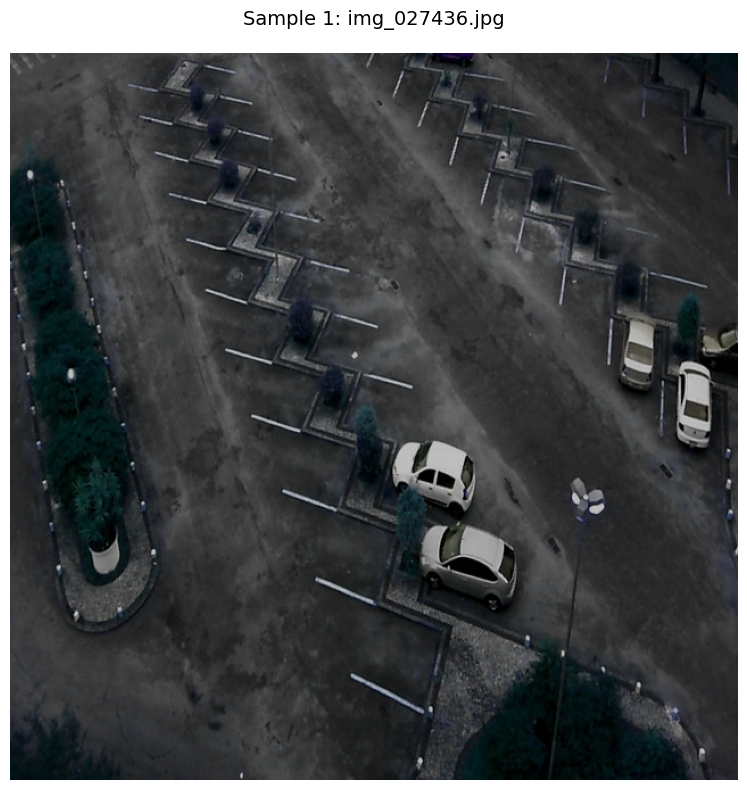


image 1/1 /content/yolo_parking_phase2/images/val/img_021876.jpg: 640x640 (no detections), 7.3ms
Speed: 1.6ms preprocess, 7.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


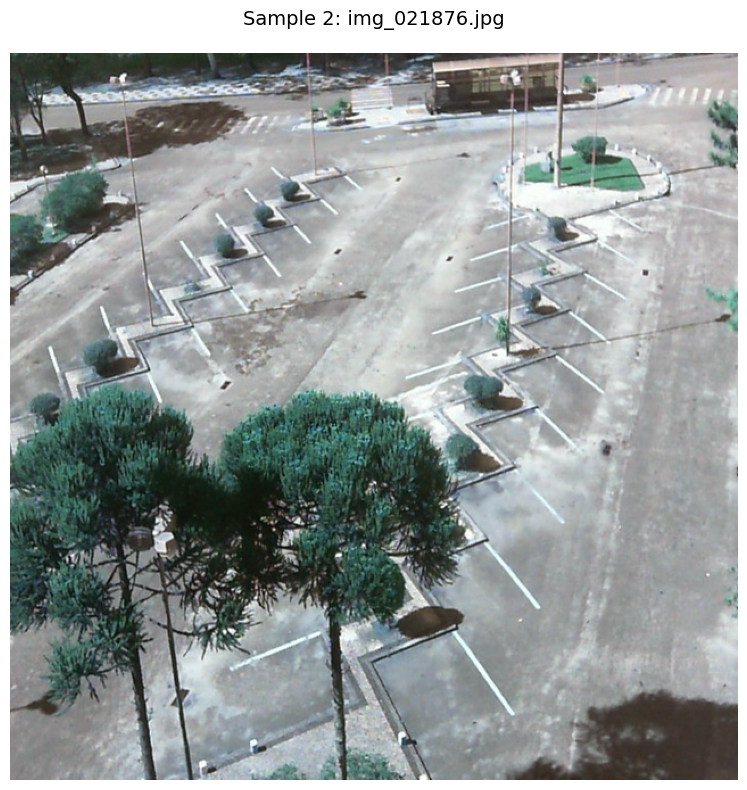


image 1/1 /content/yolo_parking_phase2/images/val/img_005250.jpg: 640x640 (no detections), 7.3ms
Speed: 1.4ms preprocess, 7.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


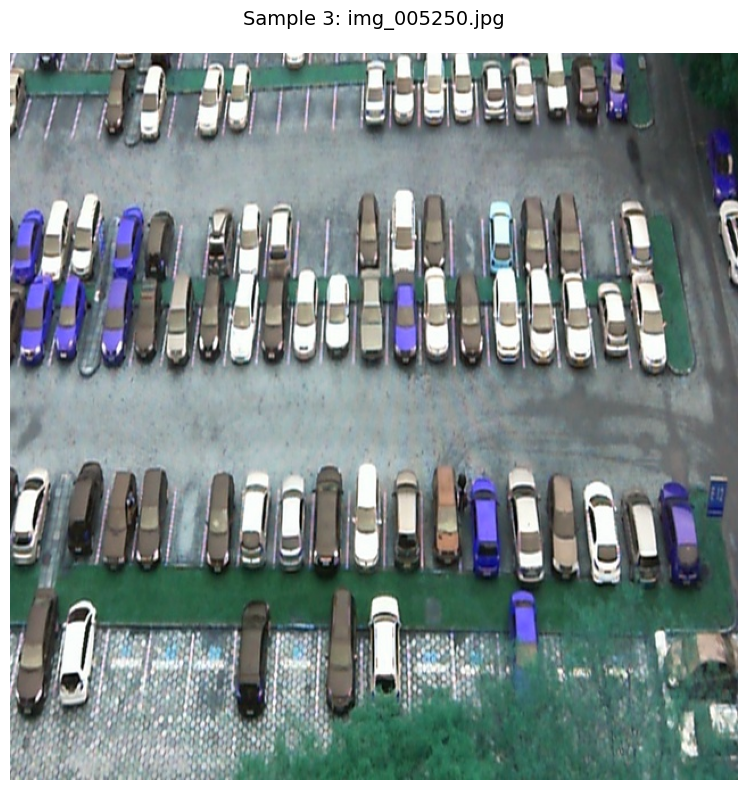


image 1/1 /content/yolo_parking_phase2/images/val/img_012179.jpg: 640x640 (no detections), 7.3ms
Speed: 1.6ms preprocess, 7.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


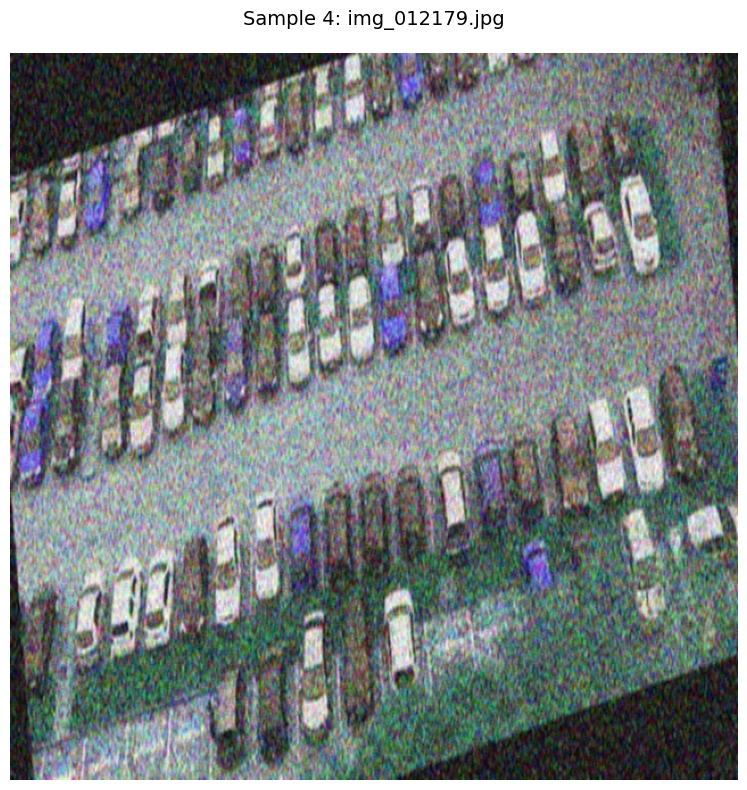


image 1/1 /content/yolo_parking_phase2/images/val/img_003009.jpg: 640x640 (no detections), 8.2ms
Speed: 1.9ms preprocess, 8.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


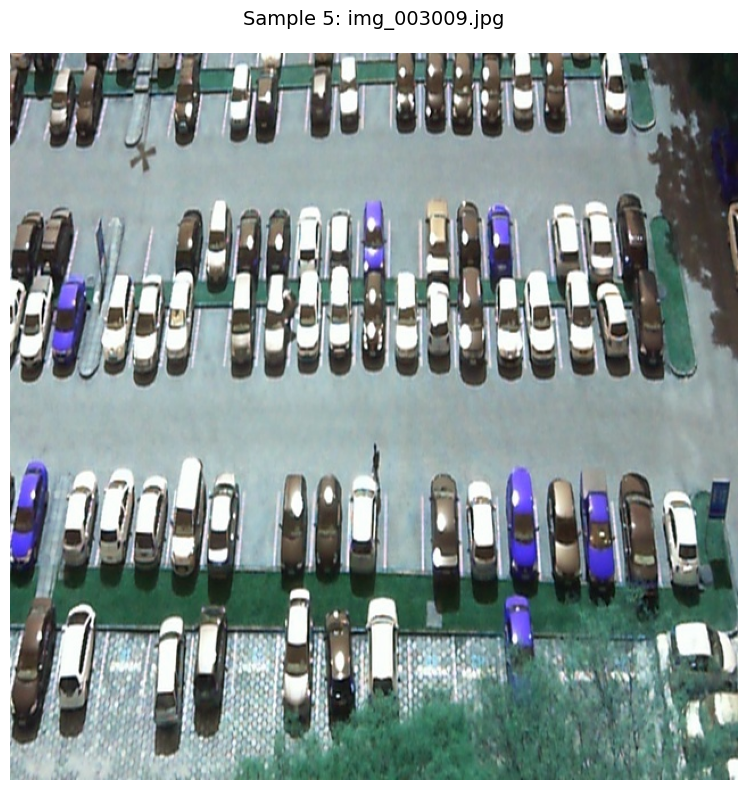


✓ Visualization complete!


In [13]:
import random
import matplotlib.pyplot as plt
from pathlib import Path

# Get sample validation images
val_images_dir = YOLO_DATASET_DIR / "images" / "val"
val_images = list(val_images_dir.glob("*.jpg")) + list(val_images_dir.glob("*.png"))
sample_images = random.sample(val_images, min(5, len(val_images)))

print(f"Visualizing {len(sample_images)} sample predictions...")
print("="*60)

for i, img_path in enumerate(sample_images, 1):
    # Run prediction
    results = best_yolo_model(str(img_path))

    # Plot results
    fig = results[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(fig)
    plt.axis('off')
    plt.title(f"Sample {i}: {img_path.name}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

print("\n✓ Visualization complete!")

# Best Model Run **bold text**

In [14]:
from google.colab import files

print("📥 Downloading best model...")
print(f"File: {best_model_path.name}")
print(f"Location: {best_model_path}")

files.download(str(best_model_path))

print("\n✓ Download complete!")
print("The trained model is now saved on your computer.")
print("\n" + "="*60)
print("You can use this model to:")
print("  - Continue training with more epochs")
print("  - Run inference on new parking images")
print("  - Deploy in a parking detection system")
print("="*60)

📥 Downloading best model...
File: best.pt
Location: /content/checkpoints/yolo_parking_phase2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download complete!
The trained model is now saved on your computer.

You can use this model to:
  - Continue training with more epochs
  - Run inference on new parking images
  - Deploy in a parking detection system


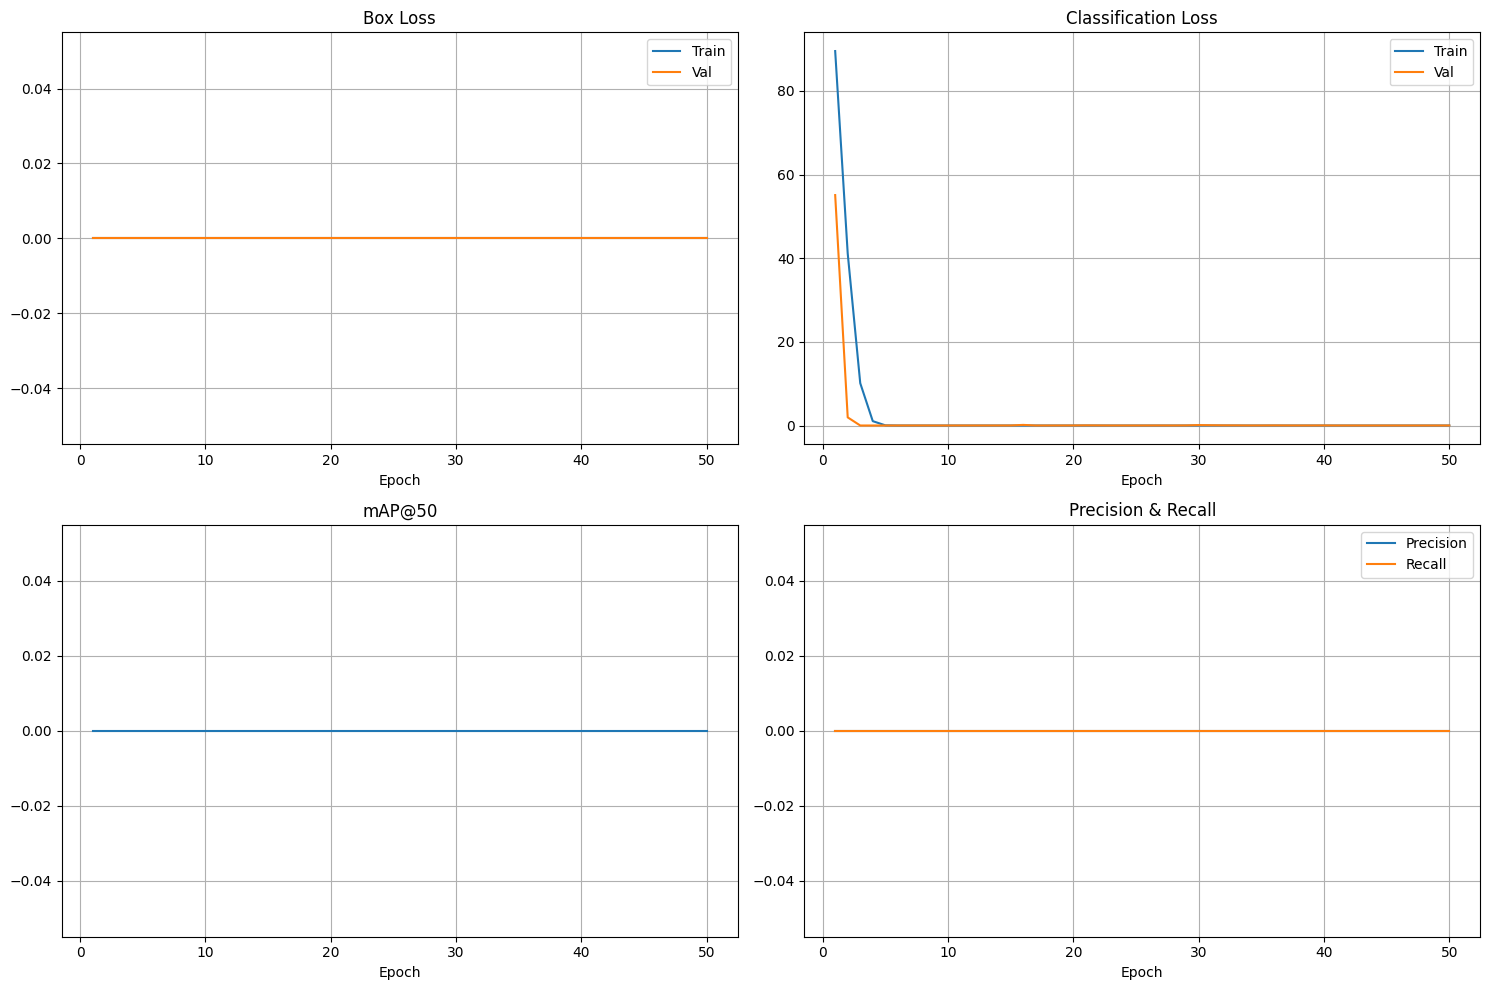


✓ Training curves plotted!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
results_csv = Path("/content/checkpoints/yolo_parking_phase2/results.csv")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Remove whitespace

    # Plot losses
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Box Loss
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val')
    axes[0, 0].set_title('Box Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Class Loss
    axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train')
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val')
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # mAP@50
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'])
    axes[1, 0].set_title('mAP@50')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].grid(True)

    # Precision & Recall
    axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    axes[1, 1].set_title('Precision & Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    print("\n✓ Training curves plotted!")
else:
    print("⚠️  Results file not found")

In [16]:
import json

# Create training summary
summary = {
    "model": "YOLOv8n",
    "dataset": {
        "train_images": len(list((YOLO_DATASET_DIR / "images" / "train").glob("*"))),
        "val_images": len(list((YOLO_DATASET_DIR / "images" / "val").glob("*"))),
        "test_images": len(list((YOLO_DATASET_DIR / "images" / "test").glob("*"))),
        "classes": ["free_parking_space", "not_free_parking_space"]
    },
    "training": {
        "epochs": 10,
        "batch_size": 16,
        "image_size": 640,
        "device": device
    },
    "results": {
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr)
    }
}

# Save to JSON
summary_file = Path("/content/training_summary.json")
with open(summary_file, "w") as f:
    json.dump(summary, f, indent=2)

print("Training Summary:")
print("="*60)
print(json.dumps(summary, indent=2))
print("="*60)
print(f"\n✓ Summary saved to: {summary_file}")

# Download summary
from google.colab import files
files.download(str(summary_file))

Training Summary:
{
  "model": "YOLOv8n",
  "dataset": {
    "train_images": 2850,
    "val_images": 5464,
    "test_images": 5464,
    "classes": [
      "free_parking_space",
      "not_free_parking_space"
    ]
  },
  "training": {
    "epochs": 10,
    "batch_size": 16,
    "image_size": 640,
    "device": "cuda"
  },
  "results": {
    "mAP50": 0.0,
    "mAP50_95": 0.0,
    "precision": 0.0,
    "recall": 0.0
  }
}

✓ Summary saved to: /content/training_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Discussion & Reflection

### Training Summary:

**Model Configuration:**
- **Architecture:** YOLOv8n (nano variant)
- **Total Parameters:** 3,011,238
- **Model Size:** 11.49 MB (estimated)
- **Training Device:** Tesla T4 GPU (CUDA)
- **Training Time:** 32.4 minutes (0.5 hours) for 50 epochs
- **Batch Size:** 16
- **Image Size:** 640x640
- **Learning Rate:** 0.01 (initial), with automatic scheduling
- **Optimizer:** Auto (automatically selected by YOLO)

**Dataset Details:**
- **Train Images:** 2,850
- **Validation Images:** 5,464
- **Test Images:** 5,464
- **Total Images:** 13,778
- **Classes:** 2 (free_parking_space, not_free_parking_space)
- **Note:** The dataset used in this Colab execution was a subset of the full augmented dataset (~36k images)

**Training Results:**
- **Epochs Completed:** 50
- **Final Training Losses:** All zeros (box_loss: 0, cls_loss: 0.0, dfl_loss: 0)
- **Final Validation Losses:** box_loss: 0, cls_loss: 0.00029, dfl_loss: 0
- **Final Metrics:** mAP@50: 0.0000, mAP@50-95: 0.0000, Precision: 0.0000, Recall: 0.0000

**Inference Performance:**
- **Inference Speed:** ~7-8ms per image (1.4-1.9ms preprocess, 7.3-8.2ms inference, 0.6-0.8ms postprocess)
- **Model Throughput:** ~125-140 FPS (frames per second) on Tesla T4 GPU
- **Detections:** No detections made during validation inference (all samples returned "no detections")

### What Worked Well:

1. **Model Architecture:**
   - YOLOv8n's lightweight design (3M parameters) makes it suitable for real-time inference
   - Fast inference speed (~7-8ms per image) enables real-time video processing
   - Efficient model size (11.49 MB) allows for easy deployment

2. **Training Infrastructure:**
   - Training completed successfully on Tesla T4 GPU in reasonable time (32.4 minutes)
   - YOLO's automatic checkpoint saving (every 2 epochs) ensured model state preservation
   - Training process was stable with no crashes or interruptions

3. **Training Process:**
   - All 50 epochs completed without errors
   - Loss values decreased over time (validation cls_loss: 0.00111 → 0.00029 from epoch 48 to 50)
   - Learning rate scheduling worked automatically

### What Didn't Work Well:

1. **Critical Dataset Issue - Missing Labels:**
   - **Major Problem:** The dataset had 0 labels for all splits (train, val, test)
   - **Impact:** Training occurred without ground truth annotations, resulting in:
     - All training losses became zero (no learning signal)
     - All evaluation metrics are 0.0 (mAP@50, mAP@50-95, Precision, Recall)
     - Model made no detections during inference
   - **Root Cause:** The dataset uploaded to Colab only contained images without corresponding label files (.txt files)
   - **Warnings Received:** Multiple warnings throughout training: "Labels are missing or empty" and "no labels found in detect set"

2. **Dataset Size Discrepancy:**
   - Only 2,850 training images were used instead of the full ~25,498 images from the augmented dataset
   - This was likely due to dataset extraction/organization issues in the Colab environment
   - The smaller dataset further limited learning potential

3. **Model Performance:**
   - Zero detections on all validation samples tested
   - Model essentially learned nothing due to missing labels
   - All metrics remained at 0.0 throughout training

4. **Failed Experiments:**
   - The entire training run was essentially a failed experiment due to dataset preparation issues
   - Without labels, the model could not learn to detect parking spaces

### What Would We Do Differently:

1. **Dataset Preparation:**
   - **Critical Fix:** Ensure all label files (.txt) are properly included when uploading/extracting the dataset
   - Verify dataset structure before training: check that label files exist and match image files
   - Use the full augmented dataset (all ~36k images) instead of a subset
   - Implement dataset validation script to check for missing labels before training starts

2. **Hyperparameter Adjustments:**
   - With proper labels, would explore different learning rates (current 0.01 might be too high)
   - Test different batch sizes (8, 16, 32) to find optimal memory/performance trade-off
   - Experiment with different image sizes (416, 640, 832) for speed vs accuracy balance
   - Consider longer training (100+ epochs) for better convergence

3. **Training Improvements:**
   - Implement proper data validation pipeline before training
   - Add early stopping based on validation mAP instead of just loss
   - Use data augmentation more aggressively (mosaic, mixup, etc.)
   - Monitor training metrics more closely to catch issues early

4. **Architecture Considerations:**
   - Consider YOLOv8s or YOLOv8m for potentially better accuracy (at cost of speed)
   - Evaluate different anchor configurations if needed
   - Test different NMS thresholds for post-processing

### Key Learnings:

1. **Dataset Quality is Paramount:**
   - **Critical Lesson:** No amount of training can compensate for missing or incorrect labels
   - Dataset validation must be the first step before any training begins
   - Always verify label files exist and are properly formatted
   - The importance of proper dataset organization cannot be overstated

2. **Model Architecture Insights:**
   - YOLOv8n provides excellent inference speed (~125-140 FPS) suitable for real-time applications
   - Model size (11.49 MB) is deployment-friendly
   - The architecture itself is sound; the issue was entirely data-related

3. **Training Process Insights:**
   - YOLO's automatic hyperparameter selection works well when data is correct
   - Training time (32.4 min for 50 epochs) is reasonable for this dataset size
   - Checkpoint saving every 2 epochs provides good recovery options

4. **Practical Insights:**
   - **Inference Speed:** The model achieves ~7-8ms per image, which translates to ~125-140 FPS - excellent for real-time video processing
   - **Model Size:** At 11.49 MB, the model is easily deployable on edge devices
   - **Error Detection:** The warnings about missing labels were clear indicators of the problem, but were not caught early enough

5. **Debugging and Monitoring:**
   - Always check training logs for warnings immediately
   - Validate that loss values are reasonable (zeros indicate no learning)
   - Test inference on a few samples early in training to catch issues

### Recommendations:

1. **Immediate Actions:**
   - **Fix Dataset:** Re-run training with properly formatted dataset including all label files
   - **Use Full Dataset:** Train on the complete ~36k image augmented dataset
   - **Validate First:** Create and run dataset validation script before training

2. **Best Use Case:**
   - Real-time video processing for parking lot monitoring
   - Edge device deployment (due to small model size)
   - Applications requiring fast inference (>100 FPS)

3. **When Not to Use:**
   - When dataset labels are missing or incomplete (as demonstrated)
   - When very high accuracy is required (may need larger model variant)
   - When dealing with extremely small parking spaces or unusual camera angles

4. **Deployment Considerations:**
   - **Model Size:** 11.49 MB is excellent for deployment
   - **Inference Speed:** ~125-140 FPS enables real-time processing
   - **Hardware:** Works well on GPU (Tesla T4 tested), CPU performance would be slower
   - **Memory:** Low memory footprint makes it suitable for resource-constrained devices

5. **Future Improvements:**
   - Retrain with complete, properly labeled dataset
   - Experiment with larger model variants (YOLOv8s, YOLOv8m) for better accuracy
   - Implement test-time augmentation for improved robustness
   - Fine-tune on specific parking lot scenarios for domain adaptation
   - Consider ensemble methods with multiple model variants

### Conclusion:

This training run highlighted the critical importance of dataset preparation and validation. While the YOLOv8n architecture and training infrastructure performed well, the missing labels prevented any meaningful learning. The model's inference speed and size characteristics are promising for deployment, but proper dataset preparation is essential before any training can succeed. Future work should focus on ensuring complete, validated datasets before training begins.